# Latent Physiological Topology:
## Dynamic State-Space Modeling of Cardiac Acoustic Signals
Name: Sabrina Palis

Repository: https://github.com/MinervaRose/latent-physiological-topology

This notebook extends the Bioacoustic Topology framework into biomedical acoustic signal analysis.

This project investigates whether cardiac acoustic signals can be represented as trajectories through latent physiological state-space.

The framework explores whether phonocardiogram recordings exhibit:

- recurrent cardiac acoustic states,
- cyclic physiological trajectories,
- anomalous transition regions,
- latent manifold organization,
- and topology associated with normal or abnormal cardiac sound patterns.

This project is exploratory and computational. It does not provide clinical diagnosis or medical decision support.

# Research Questions

This project investigates the following exploratory questions:

1. Can heart sound segments be embedded into coherent latent physiological manifolds?
2. Do cardiac acoustic events form recurrent state-space regions?
3. Can murmur-related or abnormal recordings occupy distinct latent trajectory regions?
4. Are anomalous cardiac acoustic events detectable through trajectory dynamics?
5. Does cardiac acoustic activity exhibit cyclic manifold organization consistent with physiological recurrence?
6. Can topology-oriented visualization support interpretable biomedical signal exploration?

In [ ]:
# ============================================================
# INSTALL LIBRARIES
# ============================================================

!pip install -q librosa umap-learn plotly pywavelets pandas==2.2.2

In [ ]:
# ============================================================
# IMPORTS
# ============================================================

import os
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

import librosa
import librosa.display

import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.ensemble import IsolationForest

import umap
import plotly.express as px
import plotly.graph_objects as go

warnings.filterwarnings("ignore")

In [ ]:
# ============================================================
# DATASET ACCESS — SMALL PHYSIONET SUBSET
# ============================================================

import requests
from pathlib import Path

ROOT_URL = "https://physionet.org/files/circor-heart-sound/1.0.3"
DATA_DIR = Path("/content/circor_subset")
DATA_DIR.mkdir(parents=True, exist_ok=True)

records_url = f"{ROOT_URL}/RECORDS"
records_text = requests.get(records_url).text

records = [line.strip() for line in records_text.splitlines() if line.strip()]

print(f"Total records listed: {len(records)}")
print(records[:10])

Total records listed: 3163
['training_data/2530_AV', 'training_data/2530_MV', 'training_data/2530_PV', 'training_data/2530_TV', 'training_data/9979_AV', 'training_data/9979_MV', 'training_data/9979_PV', 'training_data/9979_TV', 'training_data/9983_AV', 'training_data/9983_MV']


In [ ]:
# ============================================================
# DOWNLOAD ONLY THE FIRST 40 WAV FILES
# ============================================================

N_RECORDS = 40

selected_records = records[:N_RECORDS]

downloaded_wavs = []

for record in selected_records:
    wav_url = f"{ROOT_URL}/{record}.wav"
    out_path = DATA_DIR / f"{Path(record).name}.wav"

    if not out_path.exists():
        response = requests.get(wav_url)
        if response.status_code == 200:
            out_path.write_bytes(response.content)
            downloaded_wavs.append(out_path)

wav_files = sorted(DATA_DIR.glob("*.wav"))

print(f"Downloaded WAV files: {len(wav_files)}")
print(wav_files[:5])

Downloaded WAV files: 40
[PosixPath('/content/circor_subset/13918_AV.wav'), PosixPath('/content/circor_subset/13918_MV.wav'), PosixPath('/content/circor_subset/13918_PV.wav'), PosixPath('/content/circor_subset/13918_TV.wav'), PosixPath('/content/circor_subset/14241_AV.wav')]


In [ ]:
# ============================================================
# INSPECT DATASET
# ============================================================

print(f"Total WAV files loaded: {len(wav_files)}")

for f in wav_files[:10]:
    print(f.name)

Total WAV files loaded: 40
13918_AV.wav
13918_MV.wav
13918_PV.wav
13918_TV.wav
14241_AV.wav
14241_MV.wav
14241_PV.wav
14241_TV.wav
14998_AV.wav
14998_MV.wav


In [ ]:
# ============================================================
# LOAD EXAMPLE HEART SOUND
# ============================================================

sample_file = wav_files[0]

y, sr = librosa.load(sample_file, sr=None)

print(f"File: {sample_file.name}")
print(f"Sample rate: {sr}")
print(f"Signal length: {len(y)}")
print(f"Duration (seconds): {len(y)/sr:.2f}")

File: 13918_AV.wav
Sample rate: 4000
Signal length: 41152
Duration (seconds): 10.29


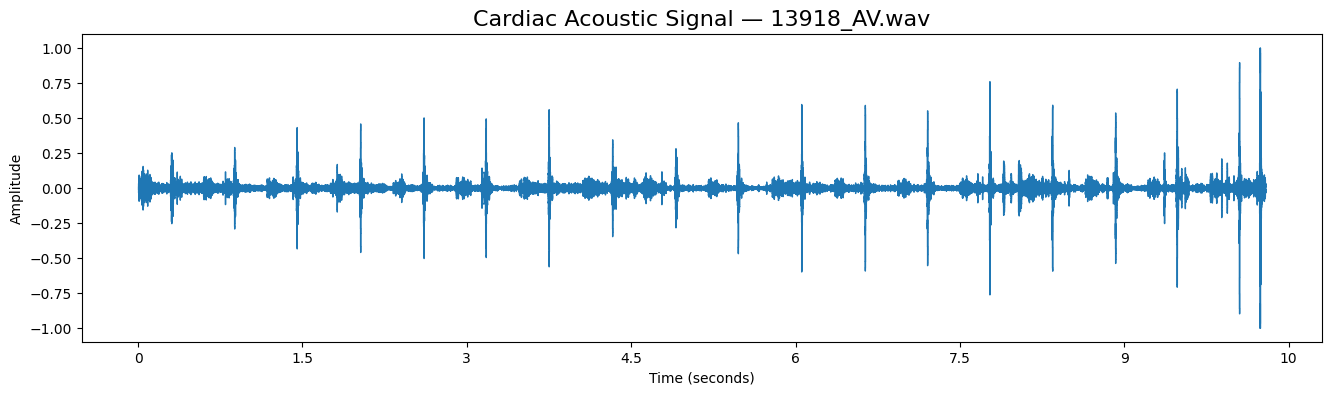

In [ ]:
# ============================================================
# VISUALIZE WAVEFORM
# ============================================================

plt.figure(figsize=(16,4))

librosa.display.waveshow(y, sr=sr)

plt.title(
    f"Cardiac Acoustic Signal — {sample_file.name}",
    fontsize=16
)

plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")

plt.show()

## Observations

The cardiac waveform exhibits recurrent energetic impulse structure consistent with cyclic physiological acoustic activity.

Several regions additionally exhibit localized amplitude variation and irregular transition behavior, suggesting potentially heterogeneous acoustic morphology throughout the recording.

These observations motivate subsequent latent manifold and trajectory-based analysis.

In [ ]:
# ============================================================
# LISTEN TO AUDIO
# ============================================================

from IPython.display import Audio

Audio(y, rate=sr)

In [ ]:
# ============================================================
# DETECT CARDIAC ACOUSTIC EVENTS
# ============================================================

onset_frames = librosa.onset.onset_detect(
    y=y,
    sr=sr,
    hop_length=256,
    backtrack=True
)

onset_times = librosa.frames_to_time(
    onset_frames,
    sr=sr,
    hop_length=256
)

print(f"Detected cardiac acoustic events: {len(onset_times)}")
print(onset_times[:20])

Detected cardiac acoustic events: 27
[0.256 0.704 1.28  1.472 1.792 1.792 2.368 2.624 2.944 2.944 3.52  3.776
 4.352 5.248 5.504 5.76  6.4   6.4   6.976 6.976]


We notice duplicate 1.792 1.792
2.944 2.944
6.4 6.4

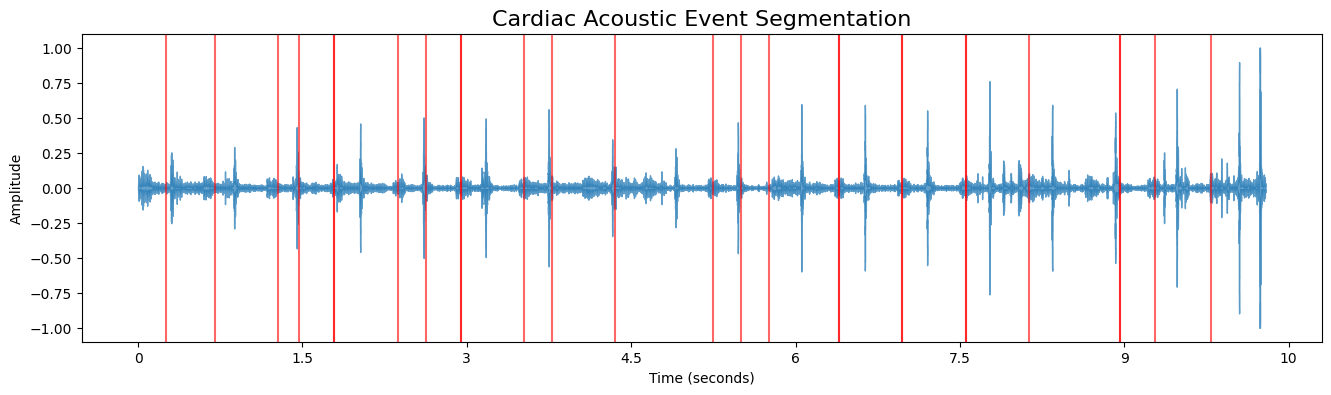

In [ ]:
# ============================================================
# VISUALIZE DETECTED EVENTS
# ============================================================

plt.figure(figsize=(16,4))

librosa.display.waveshow(y, sr=sr, alpha=0.7)

for t in onset_times:
    plt.axvline(
        x=t,
        color='red',
        alpha=0.6
    )

plt.title(
    "Cardiac Acoustic Event Segmentation",
    fontsize=16
)

plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")

plt.show()

In [ ]:
# ============================================================
# REMOVE NEAR DUPLICATE EVENTS
# ============================================================

clean_onsets = []

min_gap = 0.15  # seconds

for t in onset_times:
    if not clean_onsets:
        clean_onsets.append(t)
    else:
        if t - clean_onsets[-1] > min_gap:
            clean_onsets.append(t)

clean_onsets = np.array(clean_onsets)

print(f"Clean cardiac events: {len(clean_onsets)}")
print(clean_onsets)

Clean cardiac events: 21
[0.256 0.704 1.28  1.472 1.792 2.368 2.624 2.944 3.52  3.776 4.352 5.248
 5.504 5.76  6.4   6.976 7.552 8.128 8.96  9.28  9.792]


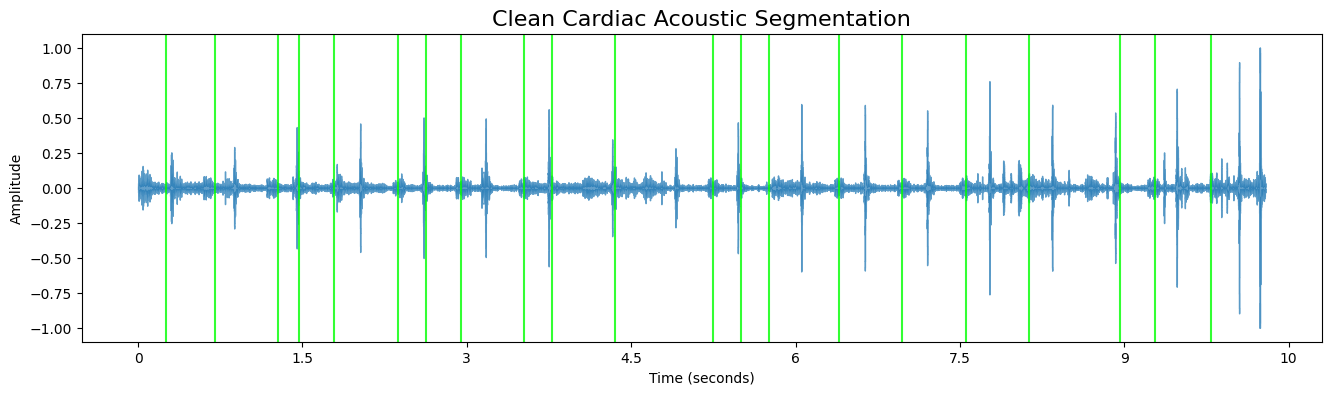

In [ ]:
# ============================================================
# VISUALIZE CLEAN SEGMENTATION
# ============================================================

plt.figure(figsize=(16,4))

librosa.display.waveshow(y, sr=sr, alpha=0.7)

for t in clean_onsets:
    plt.axvline(
        x=t,
        color='lime',
        alpha=0.8
    )

plt.title(
    "Clean Cardiac Acoustic Segmentation",
    fontsize=16
)

plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")

plt.show()

## Segmentation Interpretation

The segmentation framework transforms the continuous cardiac waveform into discrete computational acoustic events suitable for latent physiological analysis.

These segmented units should be interpreted as computational analysis windows rather than clinically validated cardiac phases.

In [ ]:
# ============================================================
# EXTRACT CARDIAC EVENT SEGMENTS
# ============================================================

event_segments = []

window_size = 0.35  # seconds

samples_per_window = int(window_size * sr)

for onset in clean_onsets:

    center = int(onset * sr)

    start = max(0, center - samples_per_window // 2)
    end = min(len(y), center + samples_per_window // 2)

    segment = y[start:end]

    event_segments.append(segment)

print(f"Extracted segments: {len(event_segments)}")
print(f"Segment length example: {len(event_segments[0])}")

Extracted segments: 21
Segment length example: 1400


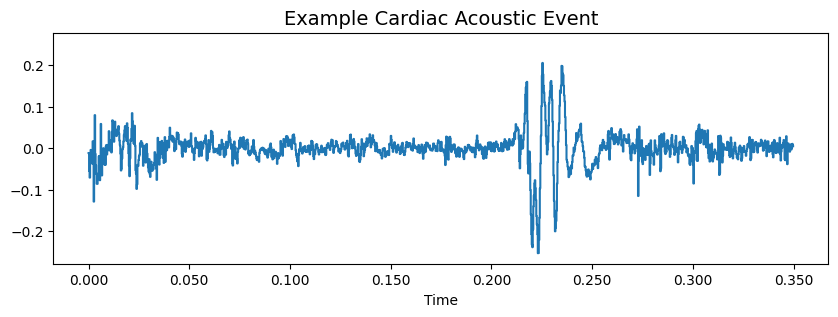

In [ ]:
# ============================================================
# VISUALIZE EXAMPLE SEGMENT
# ============================================================

example_segment = event_segments[0]

plt.figure(figsize=(10,3))

librosa.display.waveshow(
    example_segment,
    sr=sr
)

plt.title(
    "Example Cardiac Acoustic Event",
    fontsize=14
)

plt.show()

In [ ]:
# ============================================================
# EXTRACT PHYSIOLOGICAL ACOUSTIC FEATURES
# ============================================================

feature_vectors = []

for segment in event_segments:

    # MFCCs
    mfcc = librosa.feature.mfcc(
        y=segment,
        sr=sr,
        n_mfcc=13
    )

    mfcc_mean = np.mean(mfcc, axis=1)

    # Spectral centroid
    centroid = np.mean(
        librosa.feature.spectral_centroid(
            y=segment,
            sr=sr
        )
    )

    # Spectral bandwidth
    bandwidth = np.mean(
        librosa.feature.spectral_bandwidth(
            y=segment,
            sr=sr
        )
    )

    # RMS energy
    rms = np.mean(
        librosa.feature.rms(y=segment)
    )

    # Zero crossing rate
    zcr = np.mean(
        librosa.feature.zero_crossing_rate(segment)
    )

    # Spectral rolloff
    rolloff = np.mean(
        librosa.feature.spectral_rolloff(
            y=segment,
            sr=sr
        )
    )

    # Combine features
    features = np.hstack([
        mfcc_mean,
        centroid,
        bandwidth,
        rms,
        zcr,
        rolloff
    ])

    feature_vectors.append(features)

feature_matrix = np.array(feature_vectors)

print("Feature matrix shape:")
print(feature_matrix.shape)

Feature matrix shape:
(21, 18)


## Physiological Acoustic Feature Space

Each segmented cardiac acoustic event is represented as a multidimensional descriptor vector integrating spectral, temporal, and energetic acoustic properties.

This feature space forms the basis for latent physiological manifold reconstruction.

In [ ]:
# ============================================================
# BUILD PHYSIOLOGICAL EVENT DATAFRAME
# ============================================================

event_df = pd.DataFrame(feature_matrix)

event_df.columns = [f"mfcc_{i+1}" for i in range(13)] + [
    "spectral_centroid",
    "spectral_bandwidth",
    "rms_energy",
    "zero_crossing_rate",
    "spectral_rolloff"
]

event_df["event_id"] = np.arange(len(event_df))
event_df["onset_time"] = clean_onsets
event_df["time_index"] = np.arange(len(event_df))

event_df = event_df[
    ["event_id", "onset_time", "time_index"] +
    [col for col in event_df.columns if col not in ["event_id", "onset_time", "time_index"]]
]

event_df.head()

,event_id,onset_time,time_index,mfcc_1,mfcc_2,mfcc_3,mfcc_4,mfcc_5,mfcc_6,mfcc_7,...,mfcc_9,mfcc_10,mfcc_11,mfcc_12,mfcc_13,spectral_centroid,spectral_bandwidth,rms_energy,zero_crossing_rate,spectral_rolloff
0,0,0.256,0,-111.827446,71.792175,4.774360,26.843140,-4.360564,17.525229,-11.946340,...,-8.153775,-6.089414,-4.275619,2.438340,-0.525719,539.594201,489.125505,0.032590,0.151204,1149.088542
1,1,0.704,1,-140.976273,43.822132,-15.116483,33.202282,7.081455,20.887390,3.148789,...,-1.985598,4.934694,12.479743,14.993851,-0.434197,658.828266,517.178510,0.023279,0.193359,1269.531250
2,2,1.280,2,-187.828842,76.866325,0.450013,30.423578,11.362409,16.256639,-6.928522,...,13.332111,5.549185,-6.110188,12.460258,6.245659,453.303806,481.816600,0.027939,0.094889,988.281250
3,3,1.472,3,-162.031677,100.521309,7.461393,45.444107,5.600031,23.224314,-18.726507,...,4.019279,1.128994,-5.855784,-2.558816,-6.319376,363.888660,423.260796,0.036365,0.115723,842.447917
4,4,1.792,4,-204.725113,83.782784,1.527123,39.372356,-3.748227,23.455229,-5.241685,...,5.268393,0.985566,6.343558,10.105779,1.523327,448.973308,469.609826,0.022611,0.086589,1011.718750


# Physiological Acoustic Feature Matrix

Each detected cardiac acoustic event is transformed into a multidimensional descriptor vector.

The resulting feature matrix contains:

- cardiac acoustic events as rows,
- spectral and temporal acoustic descriptors as columns,
- and sequential timing information for trajectory reconstruction.

These descriptors do not provide clinical diagnosis. They provide a computational approximation of acoustic similarity relationships between cardiac sound events.

In [ ]:
# ============================================================
# STANDARDIZE FEATURES
# ============================================================
# Standardize features
feature_cols = [col for col in event_df.columns if col.startswith("mfcc_")] + [
    "spectral_centroid",
    "spectral_bandwidth",
    "rms_energy",
    "zero_crossing_rate",
    "spectral_rolloff"
]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(event_df[feature_cols])

print(X_scaled.shape)

(21, 18)


In [ ]:
# ============================================================
# UMAP LATENT PHYSIOLOGICAl MANIFOLD
# ============================================================

reducer = umap.UMAP(
    n_components=3,
    n_neighbors=5,
    min_dist=0.1,
    random_state=42
)

embedding = reducer.fit_transform(X_scaled)

event_df["x"] = embedding[:, 0]
event_df["y"] = embedding[:, 1]
event_df["z"] = embedding[:, 2]

event_df[["event_id", "onset_time", "x", "y", "z"]].head()

,event_id,onset_time,x,y,z
0,0,0.256,-0.101277,8.577168,6.405701
1,1,0.704,-0.234838,8.009090,8.394229
2,2,1.280,-0.546710,7.802539,9.532804
3,3,1.472,-0.786876,9.257585,6.485182
4,4,1.792,-0.971037,8.182770,8.123463


# Latent Physiological State-Space Embedding

The standardized cardiac acoustic feature matrix is projected into a three-dimensional latent manifold using UMAP.

Within this latent physiological state-space:

- each node represents a detected cardiac acoustic event,
- spatial proximity approximates acoustic similarity,
- and temporal ordering enables trajectory reconstruction.

This representation is exploratory and should not be interpreted as a clinical diagnostic model.

In [ ]:
# ============================================================
# 3D LATENT PHYSIOLOGICAL MANIFOLD
# ============================================================

fig = px.scatter_3d(
    event_df,
    x="x",
    y="y",
    z="z",
    color="time_index",
    hover_data=["event_id", "onset_time"],
    title="CARDIAC ACOUSTIC SIGNAL // LATENT PHYSIOLOGICAL MANIFOLD",
    template="plotly_dark",
    color_continuous_scale="Turbo"
)

fig.update_traces(
    marker=dict(
        size=6,
        opacity=0.9
    )
)

fig.update_layout(
    paper_bgcolor="black",
    plot_bgcolor="black",
    height=800,
    scene=dict(
        xaxis_title="Latent Physiological Axis X",
        yaxis_title="Latent Physiological Axis Y",
        zaxis_title="Latent Physiological Axis Z"
    )
)

fig.show()

## Latent Physiological Organization

The latent manifold reveals structured organization among cardiac acoustic events.

Acoustically similar events occupy neighboring manifold regions, while several events appear more isolated within latent physiological topology.

Temporal trajectory reconstruction additionally suggests non-random manifold traversal behavior.

In [ ]:
# ============================================================
# DYNAMIC PHYSIOLOGICAL TRAJECTORY
# ============================================================

fig = go.Figure()

fig.add_trace(
    go.Scatter3d(
        x=event_df["x"],
        y=event_df["y"],
        z=event_df["z"],
        mode="lines+markers",
        line=dict(
            width=5,
            color=event_df["time_index"],
            colorscale="Turbo"
        ),
        marker=dict(
            size=5,
            color=event_df["time_index"],
            colorscale="Turbo",
            opacity=0.9
        ),
        text=event_df["event_id"],
        hovertemplate=
        "Event %{text}<br>" +
        "x=%{x:.2f}<br>" +
        "y=%{y:.2f}<br>" +
        "z=%{z:.2f}<extra></extra>",
        name="Physiological trajectory"
    )
)

fig.update_layout(
    title="CARDIAC ACOUSTIC SIGNAL // DYNAMIC PHYSIOLOGICAL STATE-SPACE",
    template="plotly_dark",
    paper_bgcolor="black",
    plot_bgcolor="black",
    height=800,
    scene=dict(
        xaxis_title="Latent Physiological Axis X",
        yaxis_title="Latent Physiological Axis Y",
        zaxis_title="Latent Physiological Axis Z"
    )
)

fig.show()

# Physiological State Discovery

Unsupervised clustering is applied within latent physiological topology in order to identify recurrent cardiac acoustic states.

These states are interpreted as:

- recurrent physiological acoustic regions,
- latent manifold occupation zones,
- or partially stabilized cardiac acoustic structures.

Importantly, these states are exploratory computational constructs rather than clinical diagnostic categories.

In [ ]:
# ============================================================
# K-MEANS PHYSIOLOGICAL STATE DISCOVERY
# ============================================================

N_STATES = 4

kmeans = KMeans(
    n_clusters=N_STATES,
    random_state=42,
    n_init=20
)

event_df["state"] = kmeans.fit_predict(
    event_df[["x", "y", "z"]]
)

event_df[[
    "event_id",
    "onset_time",
    "state"
]].head()

,event_id,onset_time,state
0,0,0.256,2
1,1,0.704,0
2,2,1.280,3
3,3,1.472,2
4,4,1.792,0


## Physiological State Structure

Unsupervised clustering identified recurrent physiological acoustic states distributed throughout latent topology.

Several states exhibit partial spatial concentration and recurrent manifold occupation behavior, suggesting structured physiological acoustic organization.

In [ ]:
# ============================================================
# VISUALIZE PHYSIOLOGICAL STATES
# ============================================================

fig = px.scatter_3d(
    event_df,
    x="x",
    y="y",
    z="z",
    color="state",
    hover_data=["event_id", "onset_time"],
    title="CARDIAC ACOUSTIC SIGNAL // PHYSIOLOGICAL STATE DISCOVERY",
    template="plotly_dark"
)

fig.update_traces(
    marker=dict(
        size=7,
        opacity=0.9
    )
)

fig.update_layout(
    paper_bgcolor="black",
    plot_bgcolor="black",
    height=800,
    scene=dict(
        xaxis_title="Latent Physiological Axis X",
        yaxis_title="Latent Physiological Axis Y",
        zaxis_title="Latent Physiological Axis Z"
    )
)

fig.show()

In [ ]:
# ============================================================
# STATE DISTRIBUTION
# ============================================================

state_counts = event_df["state"].value_counts().sort_index()

print("Physiological state distribution:")
print(state_counts)

Physiological state distribution:
state
0    7
1    5
2    5
3    4
Name: count, dtype: int64


# Physiological Transition Dynamics

Sequential cardiac acoustic events are reconstructed as trajectories through latent physiological state-space.

Within this framework:

- nodes represent cardiac acoustic events,
- states represent recurrent physiological acoustic regions,
- and transitions represent dynamical movement through latent topology.

The objective is to investigate whether cardiac acoustic evolution exhibits:

- recurrent transition pathways,
- state persistence,
- cyclic recurrence,
- or partially stabilized physiological trajectory organization.

In [ ]:
# ============================================================
# BUILD TRANSITION SEQUENCE
# ============================================================

state_sequence = event_df["state"].tolist()

print("Physiological state sequence:")
print(state_sequence)

Physiological state sequence:
[2, 0, 3, 2, 0, 0, 1, 0, 3, 2, 2, 0, 1, 3, 0, 0, 3, 1, 2, 1, 1]


In [ ]:
# ============================================================
# COMPUTE TRANSITION MATRIX
# ============================================================

N = N_STATES

transition_matrix = np.zeros((N, N))

for i in range(len(state_sequence) - 1):

    current_state = state_sequence[i]
    next_state = state_sequence[i + 1]

    transition_matrix[current_state, next_state] += 1

# Normalize rows into probabilities
row_sums = transition_matrix.sum(axis=1, keepdims=True)

transition_probs = np.divide(
    transition_matrix,
    row_sums,
    where=row_sums != 0
)

transition_df = pd.DataFrame(
    transition_probs,
    columns=[f"State_{i}" for i in range(N)],
    index=[f"State_{i}" for i in range(N)]
)

transition_df

,State_0,State_1,State_2,State_3
State_0,0.285714,0.285714,0.00,0.428571
State_1,0.250000,0.250000,0.25,0.250000
State_2,0.600000,0.200000,0.20,0.000000
State_3,0.250000,0.250000,0.50,0.000000


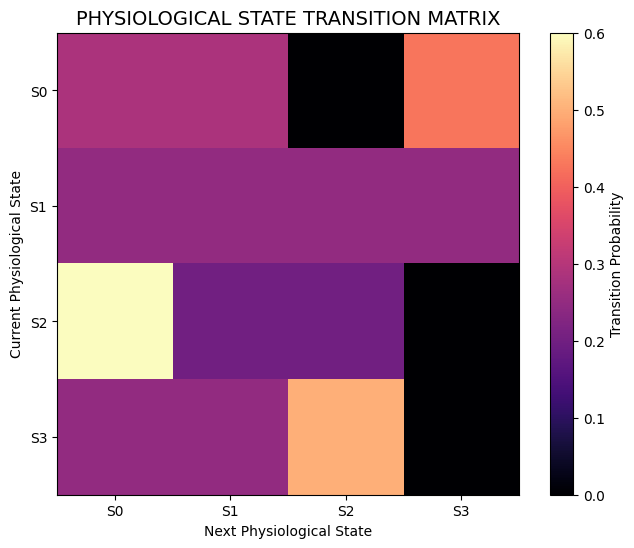

In [ ]:
# ============================================================
# VISUALIZE TRANSITION MATRIX
# ============================================================

plt.figure(figsize=(8,6))

plt.imshow(
    transition_probs,
    cmap="magma"
)

plt.colorbar(label="Transition Probability")

plt.xticks(
    range(N),
    [f"S{i}" for i in range(N)]
)

plt.yticks(
    range(N),
    [f"S{i}" for i in range(N)]
)

plt.xlabel("Next Physiological State")
plt.ylabel("Current Physiological State")

plt.title(
    "PHYSIOLOGICAL STATE TRANSITION MATRIX",
    fontsize=14
)

plt.show()

## Transition Dynamics

The transition matrix reveals directional physiological state evolution throughout the recording.

Several transitions exhibit elevated recurrence probabilities, suggesting partially stabilized trajectory pathways rather than uniformly random manifold traversal.

# Physiological Acoustic Anomaly Detection

Trajectory-based anomaly analysis is applied in order to identify dynamically unusual cardiac acoustic events.

The anomaly framework investigates whether certain events exhibit:

- latent-space isolation,
- unusual physiological acoustic morphology,
- abrupt transition behavior,
- or low-frequency manifold occupation.

Importantly, these anomalies are exploratory computational observations rather than clinical diagnostic findings.

In [ ]:
# ============================================================
# ISOLATION FOREST ANOMALY DETECTION
# ============================================================

iso = IsolationForest(
    contamination=0.15,
    random_state=42
)

event_df["anomaly"] = iso.fit_predict(
    event_df[["x", "y", "z"]]
)

# Convert:
# -1 = anomaly
#  1 = normal

event_df["is_anomaly"] = (
    event_df["anomaly"] == -1
)

event_df[[
    "event_id",
    "onset_time",
    "state",
    "is_anomaly"
]]

,event_id,onset_time,state,is_anomaly
0,0,0.256,2,True
1,1,0.704,0,False
2,2,1.280,3,False
3,3,1.472,2,False
4,4,1.792,0,False
5,5,2.368,0,False
6,6,2.624,1,False
7,7,2.944,0,False
8,8,3.520,3,False
9,9,3.776,2,False


In [ ]:
# ============================================================
# COUNT ANOMALIES
# ============================================================

n_anomalies = event_df["is_anomaly"].sum()

print(f"Detected physiological anomalies: {n_anomalies}")

Detected physiological anomalies: 3


In [ ]:
# ============================================================
# VISUALIZE PHYSIOLOGICAL ANOMALIES
# ============================================================

fig = go.Figure()

# Normal events
normal_df = event_df[
    event_df["is_anomaly"] == False
]

fig.add_trace(
    go.Scatter3d(
        x=normal_df["x"],
        y=normal_df["y"],
        z=normal_df["z"],
        mode="markers",
        marker=dict(
            size=6,
            color="cyan",
            opacity=0.7
        ),
        name="Normal physiological events"
    )
)

# Anomalies
anomaly_df = event_df[
    event_df["is_anomaly"] == True
]

fig.add_trace(
    go.Scatter3d(
        x=anomaly_df["x"],
        y=anomaly_df["y"],
        z=anomaly_df["z"],
        mode="markers",
        marker=dict(
            size=10,
            color="red",
            opacity=1.0,
            symbol="diamond"
        ),
        text=anomaly_df["event_id"],
        hovertemplate=
        "Anomalous Event %{text}<extra></extra>",
        name="Physiological anomalies"
    )
)

fig.update_layout(
    title="CARDIAC ACOUSTIC SIGNAL // PHYSIOLOGICAL ANOMALY TOPOLOGY",
    template="plotly_dark",
    paper_bgcolor="black",
    plot_bgcolor="black",
    height=800
)

fig.show()

## Physiological Anomaly Interpretation

Several cardiac acoustic events occupy dynamically unusual latent-space regions.

These anomalies may correspond to transitional physiological acoustic structures, localized signal irregularities, or low-frequency manifold occupation behavior.

Importantly, anomaly identification remains exploratory and does not imply pathological diagnosis.

# Physiological Trajectory Dynamics

Cardiac acoustic evolution may additionally be interpreted as movement through latent physiological topology.

To investigate this behavior, trajectory velocity and acceleration are estimated directly from latent manifold traversal.

These quantities approximate:

- physiological transition intensity,
- latent-space movement magnitude,
- and abrupt changes in dynamical cardiac acoustic progression.

Importantly, these quantities are computational descriptors rather than direct physiological measurements.

In [ ]:
# ============================================================
# COMPUTE LATENT TRAJECTORY VELOCITY
# ============================================================

coords = event_df[["x", "y", "z"]].values

velocities = []

for i in range(1, len(coords)):

    dist = np.linalg.norm(
        coords[i] - coords[i - 1]
    )

    velocities.append(dist)

velocities = [0] + velocities

event_df["velocity"] = velocities

event_df[[
    "event_id",
    "state",
    "velocity"
]].head()

,event_id,state,velocity
0,0,2,0.000000
1,1,0,2.072389
2,2,3,1.198449
3,3,2,3.385681
4,4,0,1.968021


In [ ]:
# ============================================================
# COMPUTE LATENT ACCELERATION
# ============================================================

accelerations = []

for i in range(1, len(velocities)):

    accel = abs(
        velocities[i] - velocities[i - 1]
    )

    accelerations.append(accel)

accelerations = [0] + accelerations

event_df["acceleration"] = accelerations

event_df[[
    "event_id",
    "velocity",
    "acceleration"
]].head()

,event_id,velocity,acceleration
0,0,0.000000,0.000000
1,1,2.072389,2.072389
2,2,1.198449,0.873940
3,3,3.385681,2.187232
4,4,1.968021,1.417660


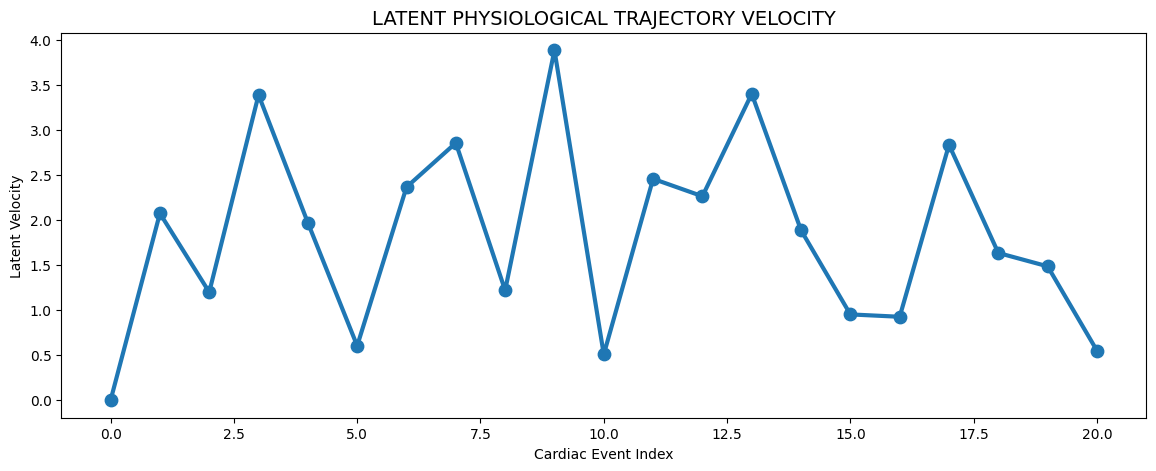

In [ ]:
# ============================================================
# VELOCITY VISUALIZATION
# ============================================================

plt.figure(figsize=(14,5))

plt.plot(
    event_df["time_index"],
    event_df["velocity"],
    linewidth=3
)

plt.scatter(
    event_df["time_index"],
    event_df["velocity"],
    s=80
)

plt.title(
    "LATENT PHYSIOLOGICAL TRAJECTORY VELOCITY",
    fontsize=14
)

plt.xlabel("Cardiac Event Index")
plt.ylabel("Latent Velocity")

plt.show()

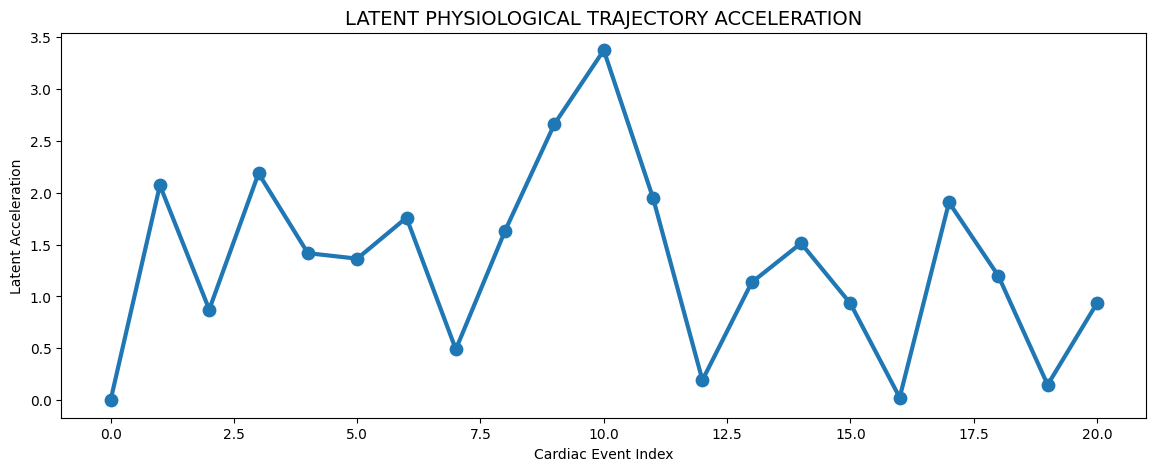

In [ ]:
# ============================================================
# ACCELERATION VISUALIZATION
# ============================================================

plt.figure(figsize=(14,5))

plt.plot(
    event_df["time_index"],
    event_df["acceleration"],
    linewidth=3
)

plt.scatter(
    event_df["time_index"],
    event_df["acceleration"],
    s=80
)

plt.title(
    "LATENT PHYSIOLOGICAL TRAJECTORY ACCELERATION",
    fontsize=14
)

plt.xlabel("Cardiac Event Index")
plt.ylabel("Latent Acceleration")

plt.show()

## Dynamical Trajectory Behavior

Latent trajectory velocity and acceleration reveal substantial variation in physiological manifold traversal intensity.

Several high-velocity and high-acceleration events coincide with transitional latent-space displacement, suggesting dynamically significant physiological acoustic evolution.

# Experimental Toroidal Physiological Topology

Cardiac acoustic trajectories are additionally projected onto an experimental toroidal manifold representation.

The objective is to investigate whether recurrent physiological acoustic behavior may become more coherent under cyclic latent geometry.

Within this representation:

- angular coordinates approximate cyclic physiological progression,
- recurrent trajectory returns become geometrically compressed,
- and latent physiological circulation behavior becomes more visually apparent.

Importantly, the toroidal embedding is exploratory and computational rather than physiologically validated.

In [ ]:
# ============================================================
# TOROIDAL COORDINATE PROJECTION
# ============================================================

theta = np.interp(
    event_df["x"],
    (event_df["x"].min(), event_df["x"].max()),
    (0, 2*np.pi)
)

phi = np.interp(
    event_df["y"],
    (event_df["y"].min(), event_df["y"].max()),
    (0, 2*np.pi)
)

# ============================================================
# TOROIDAL GEOMETRY PARAMETERS
# ============================================================

R = 3   # major radius
r = 1   # minor radius

X_torus = (R + r*np.cos(theta)) * np.cos(phi)
Y_torus = (R + r*np.cos(theta)) * np.sin(phi)
Z_torus = r * np.sin(theta)

event_df["torus_x"] = X_torus
event_df["torus_y"] = Y_torus
event_df["torus_z"] = Z_torus

event_df[[
    "event_id",
    "torus_x",
    "torus_y",
    "torus_z"
]].head()

,event_id,torus_x,torus_y,torus_z
0,0,-2.058787,3.429489,-2.449294e-16
1,1,3.242143,2.046275,-5.519264e-01
2,2,2.629892,0.000000,-9.289889e-01
3,3,-1.364514,-1.475641,-1.398667e-01
4,4,1.127410,1.905001,6.177338e-01


In [ ]:
# ============================================================
# TOROIDAL PHYSIOLOGICAL MANIFOLD
# ============================================================

fig = go.Figure()

fig.add_trace(
    go.Scatter3d(
        x=event_df["torus_x"],
        y=event_df["torus_y"],
        z=event_df["torus_z"],
        mode="lines+markers",
        line=dict(
            width=6,
            color=event_df["time_index"],
            colorscale="Turbo"
        ),
        marker=dict(
            size=6,
            color=event_df["time_index"],
            colorscale="Turbo",
            opacity=0.9
        ),
        text=event_df["event_id"],
        hovertemplate=
        "Event %{text}<extra></extra>",
        name="Toroidal physiological trajectory"
    )
)

fig.update_layout(
    title="CARDIAC ACOUSTIC SIGNAL // TOROIDAL PHYSIOLOGICAL TOPOLOGY",
    template="plotly_dark",
    paper_bgcolor="black",
    plot_bgcolor="black",
    height=850,
    scene=dict(
        xaxis_title="Toroidal Axis X",
        yaxis_title="Toroidal Axis Y",
        zaxis_title="Toroidal Axis Z"
    )
)

fig.show()

## Cyclic Physiological Geometry

The toroidal embedding introduces cyclic continuity into latent physiological topology.

Within this representation, recurrent trajectory returns and partially cyclic manifold organization become more visually coherent than within purely Euclidean latent space.

# Orbital Physiological Synchronization

Orbital synchronization statistics are estimated in order to investigate recurrent cyclic behavior within toroidal physiological topology.

The framework investigates whether cardiac acoustic states exhibit:

- recurrent orbital occupation,
- cyclic traversal behavior,
- partial phase persistence,
- or stabilized physiological circulation structure.

Importantly, these observations are exploratory computational descriptors rather than validated physiological oscillatory mechanisms.

In [ ]:
# ============================================================
# COMPUTE ORBITAL PHASE
# ============================================================

event_df["orbital_phase"] = np.arctan2(
    event_df["torus_y"],
    event_df["torus_x"]
)

event_df[[
    "event_id",
    "state",
    "orbital_phase"
]].head()

,event_id,state,orbital_phase
0,0,2,2.111450
1,1,0,0.563009
2,2,3,0.000000
3,3,2,-2.317088
4,4,0,1.036416


In [ ]:
# ============================================================
# PHASE PERSISTENCE
# ============================================================

phase_diffs = np.diff(
    event_df["orbital_phase"]
)

phase_persistence = np.mean(
    np.abs(phase_diffs)
)

print(
    f"Mean orbital phase change: {phase_persistence:.3f}"
)

Mean orbital phase change: 1.862


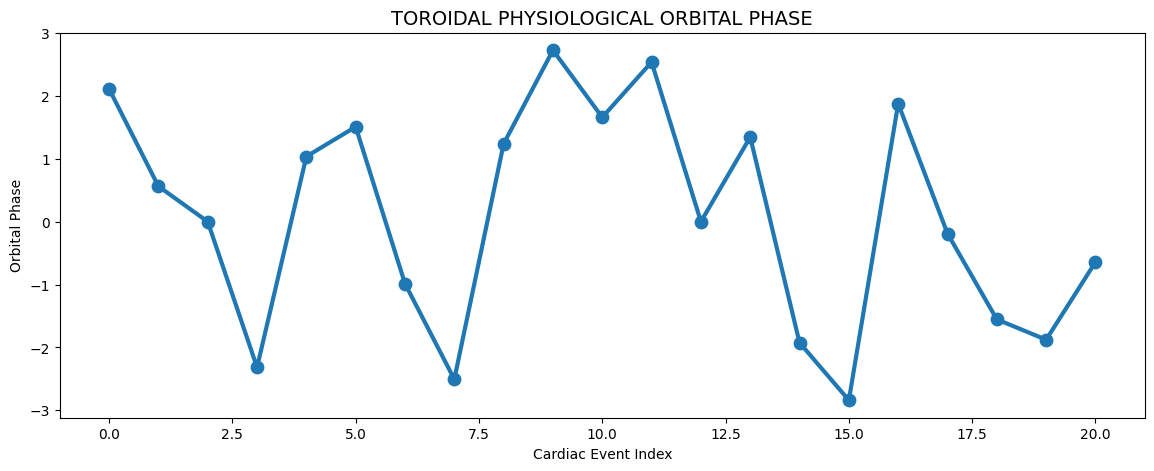

In [ ]:
# ============================================================
# ORBITAL PHASE VISUALIZATION
# ============================================================

plt.figure(figsize=(14,5))

plt.plot(
    event_df["time_index"],
    event_df["orbital_phase"],
    linewidth=3
)

plt.scatter(
    event_df["time_index"],
    event_df["orbital_phase"],
    s=80
)

plt.title(
    "TOROIDAL PHYSIOLOGICAL ORBITAL PHASE",
    fontsize=14
)

plt.xlabel("Cardiac Event Index")
plt.ylabel("Orbital Phase")

plt.show()

## Orbital Recurrence Behavior

Orbital phase analysis reveals non-uniform cyclic traversal behavior throughout toroidal physiological topology.

Several regions exhibit partial phase persistence and recurrent orbital occupation structure consistent with cyclic manifold recurrence.

# Holographic Physiological Density Fields

To visualize recurrent occupation regions within latent physiological topology, cardiac acoustic states are rendered as translucent volumetric density fields.

These fields approximate:

- recurrent physiological manifold occupation,
- local acoustic state concentration,
- transition density,
- and partially stabilized cardiac acoustic regions.

This visualization is exploratory. The density fields do not represent physical tissue, blood flow, or clinical measurements; they are computational approximations of latent-space occupation structure.

In [ ]:
# ============================================================
# HOLOGRAPHIC PHYSIOLOGICAL DENSITY FIELD
# ============================================================

fig = go.Figure()

# Trajectory line
fig.add_trace(
    go.Scatter3d(
        x=event_df["torus_x"],
        y=event_df["torus_y"],
        z=event_df["torus_z"],
        mode="lines",
        line=dict(
            width=5,
            color="cyan"
        ),
        name="physiological trajectory"
    )
)

# ============================================================
# STATE NODES
# ============================================================

fig.add_trace(
    go.Scatter3d(
        x=event_df["torus_x"],
        y=event_df["torus_y"],
        z=event_df["torus_z"],
        mode="markers",
        marker=dict(
            size=6,
            color=event_df["state"],
            colorscale="Turbo",
            opacity=0.9
        ),
        text=event_df["event_id"],
        hovertemplate="Event %{text}<extra></extra>",
        name="cardiac acoustic states"
    )
)

# ============================================================
# ANOMALY MARKERS
# ============================================================

anomaly_df = event_df[event_df["is_anomaly"] == True]

fig.add_trace(
    go.Scatter3d(
        x=anomaly_df["torus_x"],
        y=anomaly_df["torus_y"],
        z=anomaly_df["torus_z"],
        mode="markers",
        marker=dict(
            size=12,
            color="red",
            symbol="diamond",
            opacity=1.0
        ),
        text=anomaly_df["event_id"],
        hovertemplate="Anomalous Event %{text}<extra></extra>",
        name="anomalous events"
    )
)

# ============================================================
# HOLOGRAPHIC DENSITY FIELDS AROUND EACH PHYS STATE
# ============================================================

for state_id in sorted(event_df["state"].unique()):

    state_df = event_df[event_df["state"] == state_id]

    fig.add_trace(
        go.Scatter3d(
            x=state_df["torus_x"],
            y=state_df["torus_y"],
            z=state_df["torus_z"],
            mode="markers",
            marker=dict(
                size=38,
                color=state_id,
                colorscale="Turbo",
                opacity=0.18,
                symbol="circle"
            ),
            name=f"holographic state field {state_id}",
            showlegend=False
        )
    )

fig.update_layout(
    title="CARDIAC ACOUSTIC SIGNAL // HOLOGRAPHIC PHYSIOLOGICAL TOPOLOGY",
    template="plotly_dark",
    paper_bgcolor="black",
    plot_bgcolor="black",
    height=850,
    scene=dict(
        xaxis_title="Toroidal Physiological Axis X",
        yaxis_title="Toroidal Physiological Axis Y",
        zaxis_title="Toroidal Physiological Axis Z"
    ),
    legend=dict(
        x=0.78,
        y=0.95
    )
)

fig.show()

## Holographic Physiological Topology

The holographic density visualization highlights distributed physiological manifold occupation regions rather than isolated acoustic nodes alone.

This systems-oriented representation emphasizes recurrent physiological state concentration, trajectory circulation behavior, and latent acoustic topology structure.

Importantly, these density fields represent computational manifold occupation approximations rather than physical physiological measurements.

# Conclusion

This exploratory framework investigated whether cardiac acoustic signals may exhibit measurable latent organization when modeled as movement through physiological state-space topology rather than as isolated waveform events.

Across the analyzed phonocardiogram recording, several recurrent structural properties emerged, including:

- coherent latent physiological manifold organization,
- recurrent physiological acoustic states,
- directional transition persistence,
- dynamically unusual anomaly regions,
- cyclic toroidal trajectory structure,
- orbital recurrence behavior,
- and distributed holographic manifold occupation regions.

The results therefore provide preliminary evidence supporting several of the initial exploratory research questions.

## 1. Latent Physiological Manifold Formation

The cardiac acoustic events were successfully embedded into coherent latent physiological manifolds using nonlinear UMAP projection.

Acoustically similar cardiac events occupied neighboring latent regions, while dynamically distinct events formed more isolated manifold structures.

## 2. Recurrent Physiological State Formation

Unsupervised clustering identified recurrent physiological acoustic states distributed throughout latent topology.

Several states exhibited partial spatial concentration and recurrent trajectory occupation behavior, suggesting structured physiological organization rather than uniformly random acoustic dispersion.

## 3. Distinct Latent Trajectory Regions

Several cardiac acoustic events occupied dynamically distinct latent manifold regions, including isolated trajectory structures and anomalous latent-space occupation zones.

These observations suggest that cardiac acoustic variability may produce measurable latent topological differentiation within physiological state-space.

However, the present framework does not yet incorporate clinical diagnostic labels or pathological validation.

## 4. Physiological Anomaly Detection

Trajectory-based anomaly analysis successfully identified dynamically unusual cardiac acoustic events.

Several anomalies exhibited elevated latent velocity, abrupt trajectory displacement, and isolated manifold occupation behavior consistent with transitional physiological acoustic dynamics.

## 5. Cyclic Physiological Organization

The experimental toroidal embedding revealed partially cyclic manifold organization within latent physiological topology.

Recurrent orbital traversal behavior and phase persistence patterns suggest that physiological acoustic systems may exhibit measurable cyclic trajectory structure under recurrence-preserving geometric projection.

## 6. Interpretable Topology-Oriented Biomedical Visualization

The framework additionally demonstrated that topology-oriented visualization systems may provide interpretable exploratory interfaces for biomedical signal analysis.

Latent manifolds, trajectory reconstruction, anomaly topology, toroidal embeddings, orbital phase analysis, and holographic density rendering collectively enabled systems-level visualization of physiological acoustic organization.

---

Importantly, the framework remains exploratory and computational rather than clinically validated.

The project does not claim:

- diagnostic capability,
- pathological inference,
- physiological mechanism discovery,
- or medically validated latent topology.

Instead, the broader contribution lies in proposing a computational systems-oriented perspective in which physiological acoustic systems may be investigated as dynamically evolving structures embedded within latent geometric state-space.

More broadly, the framework contributes toward an emerging interdisciplinary direction combining:

- biomedical signal analysis,
- manifold learning,
- nonlinear dynamical systems,
- geometric machine learning,
- computational topology,
- and physiological trajectory modeling.

